### **Does globally optimised mult-agent routing via Genetic Algorithms produce better evacuation outcomes than individual greedy path routing?**
#### *And under what conditions does the greedy path selection fail?*

**Hypothesis**
<br>
Allowing all agents to follow the best path will result in congested nodes resulting in delays as the greedy algorithm can only focus on the path and not the wider population level congestion. The genetic algorithm will inherently account for this collective congestion in its fitness function and is likely a realistic approximation for real life if people where to communicate in evacuation situations (i.e. use different exits rather than the shortest one).

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Environment Set Up
***

In [25]:
from utils.environment import Environment 
from utils.evaluation_metrics import FinalEvaluationMetrics

from multi_agent_ga import simulate_ga_evacuation, simulate_greedy_evacuation

Small city graph has 10 starting points and 6 exit points with a bottleneck score of 1


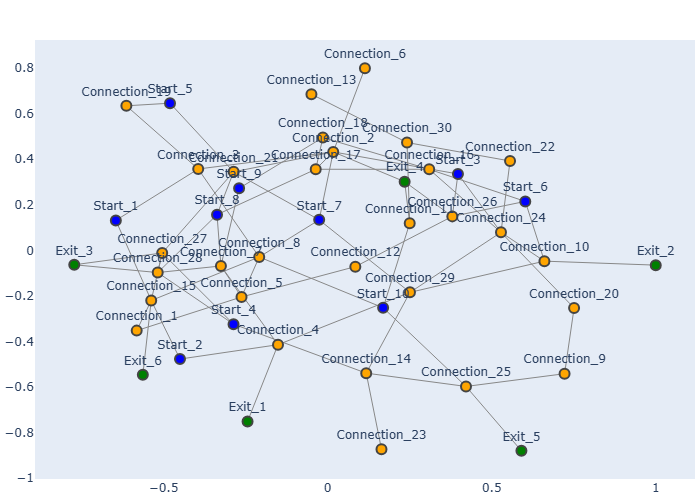

In [22]:
city_name = "small_city_graph"
city = Environment(city_name=city_name)
city.summarise_city()



In the following experiements the scenarios represent individual agents with the following characteristics:
* Walking speed - some agents walk faster/slower than other agents.
* Each agent has their own starting position (this does not vary between the genetic algorithm and greedy algorithm) # TODO: Check this...
* Each agent is considered an "individual" they have no connection to any other agent - i.e. no agents need to stay with each other like families.

The following cell defines the number of experiements which should be run for comparison and defines the random seeds which will be used across both experiments - this ensures the agents have the same start point in the city.

In [31]:
import numpy as np

n_experiments = 10

rng = np.random.default_rng(42)
algorithm_seeds = rng.integers(0, 10**6, size=n_experiments)

num_agents = 50

#### Greedy Algorithm
***

In [32]:
greedy_solution, greedy_evaluation = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params={"congestion": True, "walking": False, "fitness": "max"},
    algorithm_seed=algorithm_seeds[0],
    city=city,
)



==================================================================================== FINAL RESULTS ====================================================================================
Avg path length: 3.24 | Total time: 27.00 | Average time: 12.28 | Congestion index: 74% | Avg Congestion delay: 9.04 | Exit utilisation: 0.30 | Avg Path Efficiency: 1.46


#### Genetic Algorithm
***

In [ ]:
ga_solution, ga_evaluation = simulate_ga_evacuation(
    city=city,
    num_agents=num_agents,
    population_size=50,
    algorithm_seed=algorithm_seeds[0],
    max_evolutions=50,
    simulation_params={"congestion": True, "walking": False, "fitness": "max"},
    verbose=5,
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: small_city_graph | Population size: 50 | Walking Speed: 1.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 15.000 | avg fit: 18.060 | worst fit: 27.000 | avg path: 6.612 | congestion: 1.992 | exit use: 0.352 | diveristy: 0.062
Evolution    5 | best fit: 15.000 | avg fit: 18.820 | worst fit: 26.000 | avg path: 6.885 | congestion: 1.949 | exit use: 0.336 | diveristy: 0.230
Evolution   10 | best fit: 15.000 | avg fit: 19.220 | worst fit: 28.000 | avg path: 7.097 | congestion: 1.997 | exit use: 0.332 | diveristy: 0.366
Evolution   15 | best fit: 14.000 | avg fit: 19.020 | worst fit: 26.000 | avg path: 7.139 | congestion: 1.902 | exit use: 0.313 | diveristy: 0.447
Evolution   20 | best fit: 14.000 | avg fit